In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)
from scipy import signal
from scipy.io import wavfile

## Άσκηση - Αποθορυβοποίηση στην Signal Processing Airlines

Στα αεροπλάνα, η ηλεκτρική ισχύς είναι στα $400$ Hz (ενώ στα σπίτια είναι στα $50-60$ Hz) διότι οι αντίστοιχοι μετασχηματιστές είναι ελαφρύτεροι και μικρότεροι (σπουδαία ιδιότητα για εξοπλισμό αεροσκάφους!). Για τον λόγο αυτό, όταν γίνεται κάποια ανακοίνωση από τα ηχεία του αεροπλάνου, στο σήμα της φωνής προστίθεται ένα συνημίτονο συχνότητας $400$ Hz. Το αποτέλεσμα δεν είναι ευχάριστο στο αυτί μας. Καλείστε να φτιάξετε ένα φίλτρο (ΓΧΑ σύστημα) το οποίο να αφαιρεί το παραπάνω ενοχλητικό σήμα χωρίς να καταστρέφει το σήμα της φωνής.

Για το πείραμά σας, χρησιμοποιήστε το αρχείο 4781_8k.wav, το οποίο θα φορτώσετε και ακούσετε ως εξής:

    fs, s = wavfile.read('./4781_8k.wav')     # διαβάζουμε το συνοδευτικό wav αρχείο
    s = s / (2**15)                           # κανονικοποίηση
    Audio(s, rate=fs)                         # ακούμε! :)

## Απάντηση: 

In [2]:
fs, s = wavfile.read('./files/4781_8k.wav')     # διαβάζουμε το συνοδευτικό wav αρχείο
s = s / (2**15)                           # κανονικοποίηση
Audio(s, rate=fs)                         # ακούμε! :)

Ακολουθήστε τα παρακάτω βήματα:

(α') [**Δε χρειάζεται να κάνετε κάτι σε αυτό το βήμα, αλλά διαβάστε το**] Προφανώς μπορείτε να επιβεβαιώσετε ότι για ένα σύστημα με απόκριση σε συχνότητα

$$H(e^{j\omega}) = 1 - e^{-j(\omega-\omega_0)} \tag{3}$$

ισχύει $H(e^{j\omega_0}) = 0$, δηλ. η απόκριση συχνότητας μηδενίζεται για $\omega = \omega_0$. Αυτό σημαίνει ότι το σύστημα αυτό μηδενίζει/καταστέλλει πλήρως τη **θετική** (MONO) συχνότητα $\omega_0$ του σήματος που λαμβάνει στην είσοδό του (γιατί όπως ξέρετε, ένα σήμα αναλύεται τόσο σε θετικές όσο και σε αρνητικές συχνότητες). Θεωρήστε ότι έχετε ένα σήμα εισόδου της μορφής

$$x[n]= \cos(\omega_0 n) \tag{4}$$

(β') Ποιά θα είναι η έξοδος $y[n]$ όταν το παραπάνω σήμα $x[n]$ (που θα το αναπτύξετε με χρήση κάποιας εξίσωσης γνωστού Ελβετού μαθηματικού) περάσει από ένα **οποιοδήποτε** σύστημα με απόκριση σε συχνότητα $H(e^{j\omega})$; Εκμεταλλευτείτε το γεγονός ότι το σήμα εισόδου είναι άθροισμα *ιδιοσυναρτήσεων* του συστήματος και εκφράστε την απάντησή σας συναρτήσει αυτών, καθώς και των *ιδιοτιμών* του συστήματος (δηλ. ως ένα άθροισμα δυο όρων). **Γράψτε παρακάτω την απάντησή σας αναλυτικά**.

### Απάντηση:

Γνωρίζουμε ότι η απόκριση ενός ΓΧΑ συστηματος στην είσοδο $x[n] = \sum_{k=1}^{N}α_ke^{j\omega_kn}$ θα είναι

$$y[n] = \sum_{k=1}^{N}α_kH(e^{j\omega_k})e^{j\omega_kn}$$

Έτσι, όταν το παραπάνω σήμα $x[n]$ (άθροισμα ιδιοσυναρτήσεων του συστήματος) περάσει από ένα οποιοδήποτε σύστημα με απόκριση σε συχνότητα $H(e^{jω})$, θα έχουμε:

$$y[n] = \sum_{k=1}^{N}α_kH(e^{j\omega_k})e^{j\omega_kn} \Rightarrow y[n]= \frac{1}{2}H(e^{j\omega_0})e^{j\omega_0n}+\frac{1}{2}H(e^{-j\omega_0})e^{-j\omega_0n}$$

(γ') Με βάση την προηγούμενη απάντησή σας, βρείτε στο χαρτί σας ένα φίλτρο $H_z(e^{j\omega})$ με τις εξής ιδιότητες:

*  Μηδενίζει **και τους δυο όρους** του σήματος εισόδου $x[n]$ που έχετε βρει παραπάνω, δηλ. η έξοδος του συστήματος όταν στην είσοδό του εμφανιστεί το σήμα $x[n]$ της Σχέσης (4) να είναι $$y[n] = 0, \: \: \forall n$$ 

*  Αποτελείται από δυο υποσυστήματα **σε σειρά**, με το ένα εξ αυτών να είναι το σύστημα $H(e^{j\omega})$ που σας δίνεται παραπάνω στη Σχέση (3), καθώς και ένα ... πολύ *παρόμοιό* του. Διαβάστε προσεκτικά τι κάνει το φίλτρο της Σχέσης (3) όπως σας περιγράφεται παραπάνω και εύκολα θα βρείτε και το *παρόμοιό* του. ΜΗΝ πειράξετε το $-j$ στον εκθέτη! :)

### Απάντηση:

Θέλουμε το φίλτρο $H_z(e^{j\omega})$ να μηδενίζει πλήρως τόσο τη θετική συχνότητα $\omega_0$, όσο και την αρνητική
συχνότητα $-\omega_0$ του σήματος που λαμβάνει στην είσοδό του. Έτσι, το σύστημα αυτό αποτελείται από 2 υποσυστήματα σε σειρά. Αυτά είναι τα:

*  $H_1(e^{j\omega}) = 1 - e^{-j(\omega-\omega_0)}$, το οποίο καταστέλλει πλήρως τη θετική συχνότητα $\omega_0$.

*  $H_2(e^{j\omega}) = 1 - e^{-j(\omega+\omega_0)}$, το οποίο καταστέλλει πλήρως την αρνητική συχνότητα $-\omega_0$.

Η σύνδεση σε σειρά οδηγεί σε γινόμενο των μετασχηματισμών Fourier, άρα έχουμε:

\begin{align}
H_z(e^{j\omega}) = H_1(e^{j\omega})H_2(e^{j\omega})=(1-e^{-j(\omega-\omega_0)})(1-e^{-j(\omega+\omega_0)}) \Rightarrow H_z(e^{j\omega}) &= 1-e^{-j(\omega+\omega_0)} - e^{-j(\omega-\omega_0)} + e^{-j2\omega} \nonumber \\
H_z(e^{j\omega}) &= 1 - 2\cos(\omega_0)e^{-j\omega} + e^{-j2\omega} \nonumber 
\end{align}

(Μπορεί κανείς εύκολα να επιβεβαιώσει ότι η απόκριση συχνότητας μηδενίζεται για $\omega = \pm\omega_0$.)

(δ') Μετατρέψτε το φίλτρο $H_z(e^{j\omega})$ που βρήκατε παραπάνω σε εξίσωση διαφορών στο χαρτί σας (χρησιμοποιήστε ιδιότητες) και **γράψτε παρακάτω την εξίσωση που καταλήξατε**.

### Απάντηση:

Ισχύει ότι: 

$$H_z(e^{j\omega}) = \frac{Y(e^{j\omega})}{X(e^{j\omega})} = 1 - 2\cos(\omega_0)e^{-j\omega} + e^{-j2\omega} $$

$$Y(e^{j\omega}) = X(e^{j\omega}) - 2\cos(\omega_0)X(e^{j\omega})e^{-j\omega} + X(e^{j\omega})e^{-j2\omega}$$

Μετατρέποντας κάθε μεταβλητή στο πεδίο του χρόνου μέσω της ιδιότητας της μετατόπισης, θα είναι:

$$y[n] = x[n] - 2\cos(\omega_0)x[n-1] + x[n-2]$$

----

(ε') Η συνάρτηση $H = \textrm{signal.freqz(B,A,W)}$ υπολογίζει την απόκριση σε συχνότητα $H(e^{j\omega})$ μιας εξίσωσης διαφορών της μορφής

$$\sum_{k=0}^N a_k y[n-k] = \sum_{l=0}^N b_l x[n-l] \tag{5}$$

Δέχεται τους συντελεστές της εισόδου $Β = [b_0, \: b_1, \: \cdots \: b_N]$, της εξόδου $Α = [a_0,\: a_1, \: \cdots \: a_M]$, και τις συχνότητες $W$ που θέλουμε να υπολογίσουμε την απόκριση συχνότητας ως ορίσματα, και επιστρέφει τις τιμές της απόκρισης συχνότητας, $H$, στις συχνότητες $W$. Θεωρήστε ότι βλέπετε το χώρο της συχνότητας στο "παράθυρο" $(-\pi, \pi]$, κι έτσι οι συχνότητές σας θα είναι

    dw = 2*np.pi/600
    W = np.linspace(-np.pi,np.pi, 600)

Χρησιμοποιήστε τη συνάρτηση $\textrm{signal.freqz}$ για να δείτε αν το φίλτρο σας όντως κάνει αυτό που πρέπει (δηλ. μηδενίζει τις κατάλληλες συχνότητες στην απόκριση πλάτους). Χρησιμοποιήστε τις συναρτήσεις plot,abs για να σχεδιάσετε το *μέτρο* της απόκρισης σε συχνότητα, δηλ. την *απόκριση πλάτους* του συστήματος και τις συναρτήσεις plot,angle για να σχεδιάσετε τη *φάση* της απόκρισης σε συχνότητα, δηλ. την *απόκριση φάσης* του συστήματος. Αν όλα τα έχετε κάνει σωστά, θα δείτε τα γραφήματα του Σχήματος 1 (με μόνη διαφορά την κλίμακα των γραφημάτων).


![absangle](./files/absangle.png)

*Σχήμα 1: Απόκριση πλάτους και φάσης συστήματος $H_z(e^{j\omega})$.*


### Απάντηση:

Παρουσιάζουμε τα ζητούμενα γραφήματα:


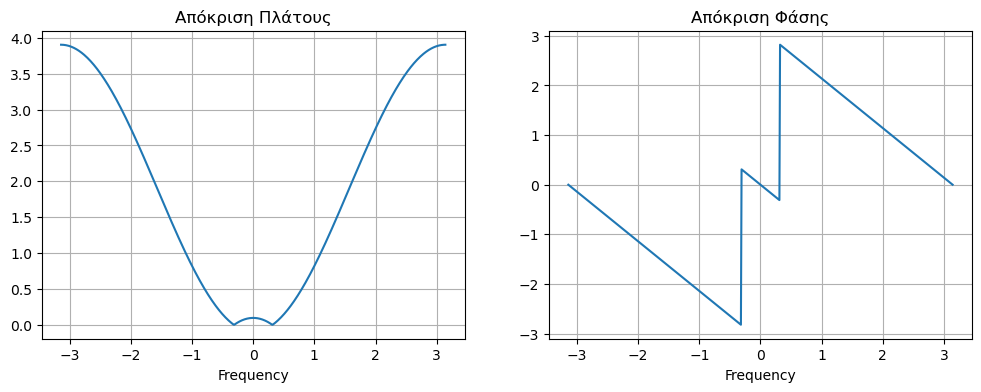

In [3]:
f0 = 400
w0 = 2*np.pi*f0/fs

dw = 2*np.pi/600
W = np.linspace(-np.pi,np.pi, 600)

A = [1]
B = [1, -2*np.cos(w0), 1]
H = signal.freqz(B,A,W)

H = np.transpose(H)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(W,np.abs(H[:,1])); plt.grid(True)
plt.xlabel('Frequency')
plt.title('Απόκριση Πλάτους')
plt.subplot(1,2,2)
plt.plot(W,np.angle(H[:,1])); plt.grid(True)
plt.xlabel('Frequency')
plt.title('Απόκριση Φάσης')
plt.show()

(στ') Χρησιμοποιήστε τη συνάρτηση $\textrm{signal.lfilter}$ για να υλοποιήσετε το σύστημα και να βρείτε την εξοδό του, δίνοντας ως είσοδο το πραγματικό σήμα φωνής που έχετε φορτώσει παραπάνω. Η $\textrm{signal.lfilter}$ συντάσσεται ως $\textrm{y = signal.lfilter(B,A,x)}$, με $B$ τους συντελεστές της εισόδου στην εξίσωση διαφορών, $A$ τους συντελεστές της εξόδου στην εξίσωση διαφορών, και $x$ το διάνυσμα του σήματος εισόδου (σήμα φωνής). Ακούστε το σήμα εξόδου.

### Απάντηση:

In [4]:
cleansig = signal.lfilter(B,A,s)
Audio(cleansig, rate=fs)

(ζ') **Αναφέρετε παρακάτω πως αντιλαμβάνεστε ακουστικά αυτήν την αλλοίωση. Λάβετε υπ'όψη σας την απόκριση πλάτους του συστήματος**. Σε άσκηση επόμενου Κεφαλαίου, θα δείτε πως να φτιάξετε ένα *πολύ* καλύτερο φίλτρο από αυτό.

### Παρατηρήσεις:

#### Γράψτε εδώ τις παρατηρήσεις σας.

Πράγματι, παρατηρούμε ότι, ενώ στο σήμα ``cleansig`` έχει εξαφανιστεί ο ενοχλητικός θόρυβος που οφειλόταν στη συχνότητα $400$ Hz, υπάρχει και μια επιπλέον αλλοίωση σε σχέση με το αρχικό σήμα, καθώς η 'πληροφορία' που υπήρχε στα $400$ Hz αλλά και αρκετά γύρω από αυτή (όπως φαίνεται στο φάσμα πλάτους) έχει κατασταλεί σημαντικά. Έτσι, μαζί με τον θόρυβο αφαιρέθηκε και τμήμα από την ομιλία. Ακουστικά αυτό έχει ως αποτέλεσμα η φωνή της ομιλήτριας να μην ακούγεται πλήρης και καθαρή όπως στο αρχικό αρχείο. Από την απόκριση πλάτους βλέπουμε ότι έχουν κατασταλει πολύ οι χαμηλές συχνότητες (γυρω από το $\omega=0$ και μέχρι το $\omega=2\pi 400/f_s$) της εισόδου και έχουν παραμείνει οι υψηλές. Άρα στο σήμα μας λείπουν τα "μπάσα", οι χαμηλές του συχνότητες.

---
---